In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load data - Pastikan file 'predictive_maintenance.csv' ada di folder yang sama
df = pd.read_csv('../dataset/predictive_maintenance.csv')

print("=== CELL 1 SELESAI: LIBRARY & DATA BERHASIL DIMUAT ===")
display(df.head())

=== CELL 1 SELESAI: LIBRARY & DATA BERHASIL DIMUAT ===


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [83]:
print("=== 1. DATA UNDERSTANDING ===")

# Menampilkan informasi dasar (tipe data dan missing values)
print("\n--- Info Dataset ---")
df.info()

# Menampilkan statistik deskriptif (Mean, Min, Max, dll)
print("\n--- Statistik Deskriptif ---")
display(df.describe())

# Menampilkan jumlah baris dan kolom
print(f"\nUkuran Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")

=== 1. DATA UNDERSTANDING ===

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB

--- Statistik Deskriptif ---


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000



Ukuran Dataset: 10000 baris dan 10 kolom


=== 2. EXPLORATORY DATA ANALYSIS (EDA) ===


C:\Users\Hi\AppData\Local\Temp\ipykernel_18152\1831029319.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Failure Type', palette='viridis')


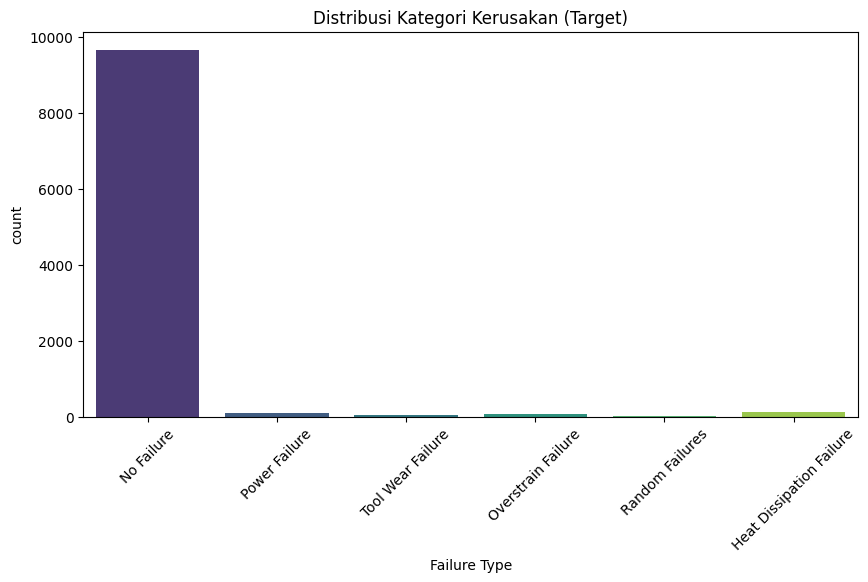

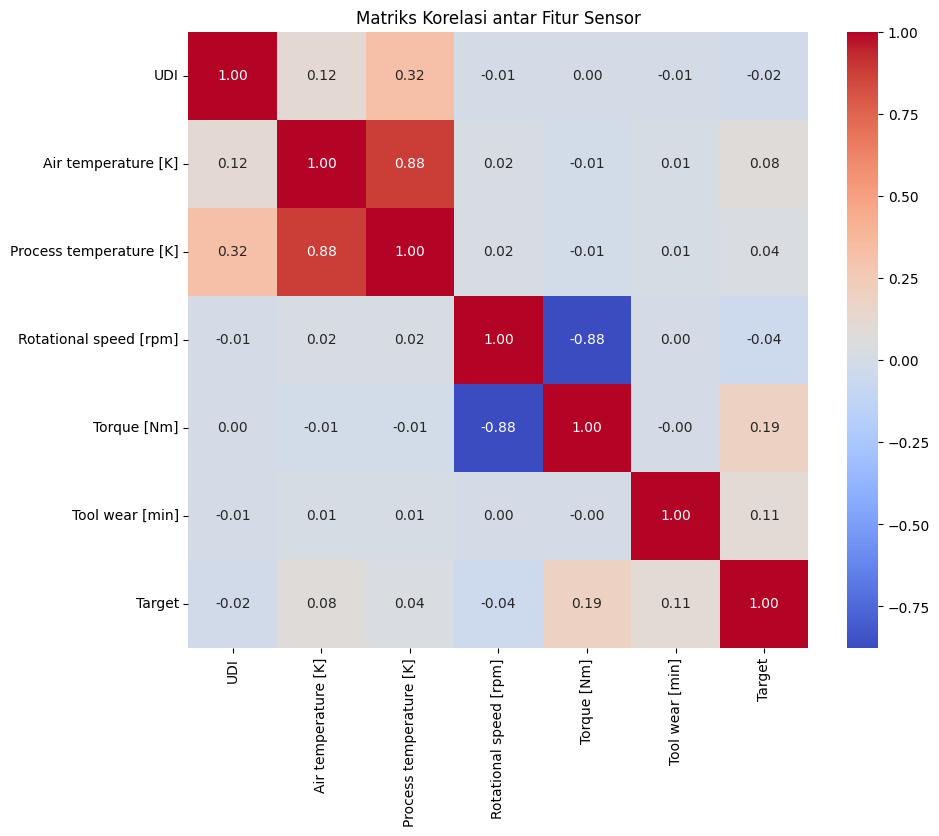

In [84]:
print("=== 2. EXPLORATORY DATA ANALYSIS (EDA) ===")

# 1. Visualisasi Distribusi Target (Melihat seberapa parah ketidakseimbangan datanya)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Failure Type', palette='viridis')
plt.title('Distribusi Kategori Kerusakan (Target)')
plt.xticks(rotation=45)
plt.show()

# 2. Matriks Korelasi (Melihat sensor mana yang paling berpengaruh)
plt.figure(figsize=(10, 8))
# Hanya menghitung korelasi untuk kolom angka
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi antar Fitur Sensor')
plt.show()

In [85]:
print("=== 3. DATA PREPROCESSING ===")

# 1. Menghapus kolom ID (UDI & Product ID) karena tidak punya nilai prediktif
X = df.drop(['UDI', 'Product ID', 'Target', 'Failure Type'], axis=1)
y = df['Failure Type']

# 2. Encoding fitur kategorikal 'Type' (L, M, H) menjadi angka
le_type = LabelEncoder()
X['Type'] = le_type.fit_transform(X['Type'])

# 3. Encoding Target 'Failure Type' menjadi angka
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# 4. Membersihkan nama kolom dari karakter khusus agar tidak error saat training
X.columns = [re.sub(r'[\[\]<]', '', col) for col in X.columns]

# 5. Standarisasi Data (Scaling) agar sensor dengan satuan berbeda punya rentang yang sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Kolom yang digunakan:", X.columns.tolist())
print("✅ Target berhasil di-encode menjadi angka.")
print("✅ Data telah melalui proses Standard Scaling.")

=== 3. DATA PREPROCESSING ===
✅ Kolom yang digunakan: ['Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min']
✅ Target berhasil di-encode menjadi angka.
✅ Data telah melalui proses Standard Scaling.


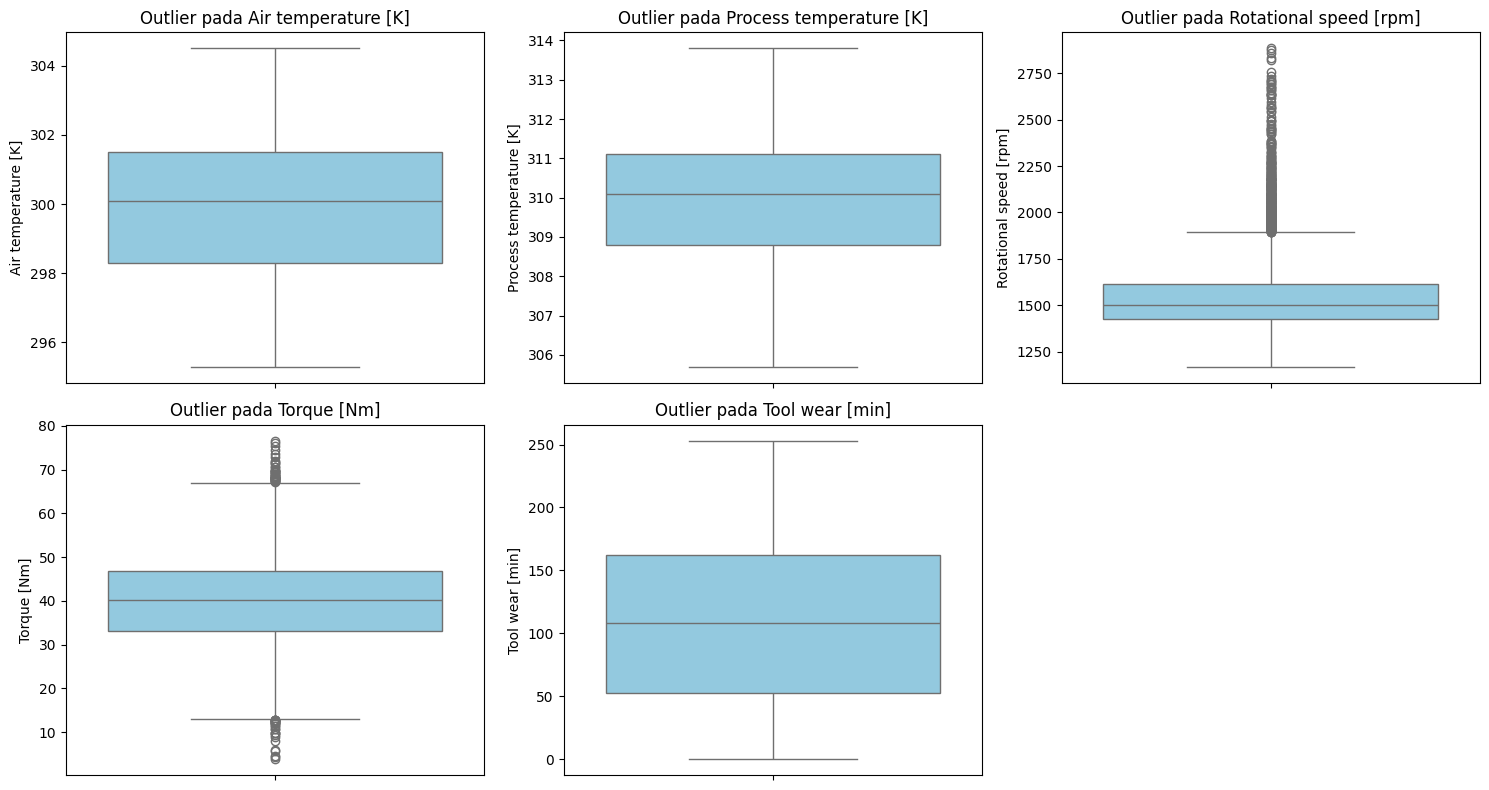

In [86]:
# Memilih kolom sensor yang berupa angka
fitur_sensor = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

plt.figure(figsize=(15, 8))
for i, kolom in enumerate(fitur_sensor):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[kolom], color='skyblue')
    plt.title(f'Outlier pada {kolom}')

plt.tight_layout()
plt.show()

In [87]:
# Membagi data: 70% Training, 30% Testing
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

print("=== Split 70:30 Berhasil ===")
print(f"Jumlah Data Training: {len(X_train70)}")
print(f"Jumlah Data Testing : {len(X_test70)}")

=== Split 70:30 Berhasil ===
Jumlah Data Training: 7000
Jumlah Data Testing : 3000


In [88]:
# Membagi data: 80% Training, 20% Testing
X_train80, X_test80, y_train80, y_test80 = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("=== Split 80:20 Berhasil ===")
print(f"Jumlah Data Training: {len(X_train80)}")
print(f"Jumlah Data Testing : {len(X_test80)}")

=== Split 80:20 Berhasil ===
Jumlah Data Training: 8000
Jumlah Data Testing : 2000


In [89]:
# Membagi data: 90% Training, 10% Testing
X_train90, X_test90, y_train90, y_test90 = train_test_split(
    X_scaled, y, test_size=0.10, random_state=42, stratify=y
)

print("=== Split 90:10 Berhasil ===")
print(f"Jumlah Data Training: {len(X_train90)}")
print(f"Jumlah Data Testing : {len(X_test90)}")

=== Split 90:10 Berhasil ===
Jumlah Data Training: 9000
Jumlah Data Testing : 1000


In [90]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. Inisialisasi list untuk menampung semua hasil ujian AI
hasil_evaluasi = []

# 2. Definisi Model dengan Hyperparameter Tuning Manual

models = {
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    "HistGradient": HistGradientBoostingClassifier(max_iter=300, max_depth=7, class_weight='balanced', random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, max_depth=None, class_weight='balanced', random_state=42)
}

# 3. Menyiapkan paket data split yang sudah dibuat di cell sebelumnya
splits = [
    ('70:30', X_train70, X_test70, y_train70, y_test70),
    ('80:20', X_train80, X_test80, y_train80, y_test80),
    ('90:10', X_train90, X_test90, y_train90, y_test90)
]

print("✅ Model dan List Hasil sudah siap. Lanjut ke cell berikutnya untuk training.")

✅ Model dan List Hasil sudah siap. Lanjut ke cell berikutnya untuk training.


In [91]:
print("=== MEMULAI PROSES TRAINING PADA 3 SPLIT DATA ===")

for rasio, X_tr, X_ts, y_tr, y_ts in splits:
    print(f"Sedang melatih model pada rasio {rasio}...")
    
    # Hitung bobot sampel khusus untuk XGBoost (biar adil sama kelas minoritas)
    sw = compute_sample_weight(class_weight='balanced', y=y_tr)
    
    for nama, model in models.items():
        # Proses Belajar (Fitting)
        if nama == "XGBoost":
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            model.fit(X_tr, y_tr)
        
        # Proses Ujian (Prediksi)
        y_pred = model.predict(X_ts)
        
        # Catat skornya ke dalam list hasil_evaluasi
        hasil_evaluasi.append({
            'Split': rasio,
            'Algoritma': nama,
            'Accuracy': accuracy_score(y_ts, y_pred),
            'Precision': precision_score(y_ts, y_pred, average='macro', zero_division=0),
            'Recall': recall_score(y_ts, y_pred, average='macro', zero_division=0),
            'F1-Score': f1_score(y_ts, y_pred, average='macro', zero_division=0)
        })

print("\n✅ Training Selesai! Data hasil sudah tersimpan di variabel 'hasil_evaluasi'.")

=== MEMULAI PROSES TRAINING PADA 3 SPLIT DATA ===
Sedang melatih model pada rasio 70:30...
Sedang melatih model pada rasio 80:20...
Sedang melatih model pada rasio 90:10...

✅ Training Selesai! Data hasil sudah tersimpan di variabel 'hasil_evaluasi'.


=== 5. MODEL COMPARISON ===

Tabel Hasil Evaluasi Lengkap:


,Split,Algoritma,Accuracy,Precision,Recall,F1-Score
0,90:10,HistGradient,0.99,0.61,0.63,0.62
1,90:10,XGBoost,0.98,0.59,0.66,0.63
2,90:10,ExtraTrees,0.98,0.59,0.42,0.48
3,80:20,HistGradient,0.98,0.61,0.61,0.60
4,80:20,XGBoost,0.98,0.57,0.65,0.61
5,80:20,ExtraTrees,0.97,0.66,0.34,0.42
6,70:30,HistGradient,0.98,0.57,0.59,0.57
7,70:30,XGBoost,0.98,0.53,0.63,0.57
8,70:30,ExtraTrees,0.98,0.59,0.36,0.42


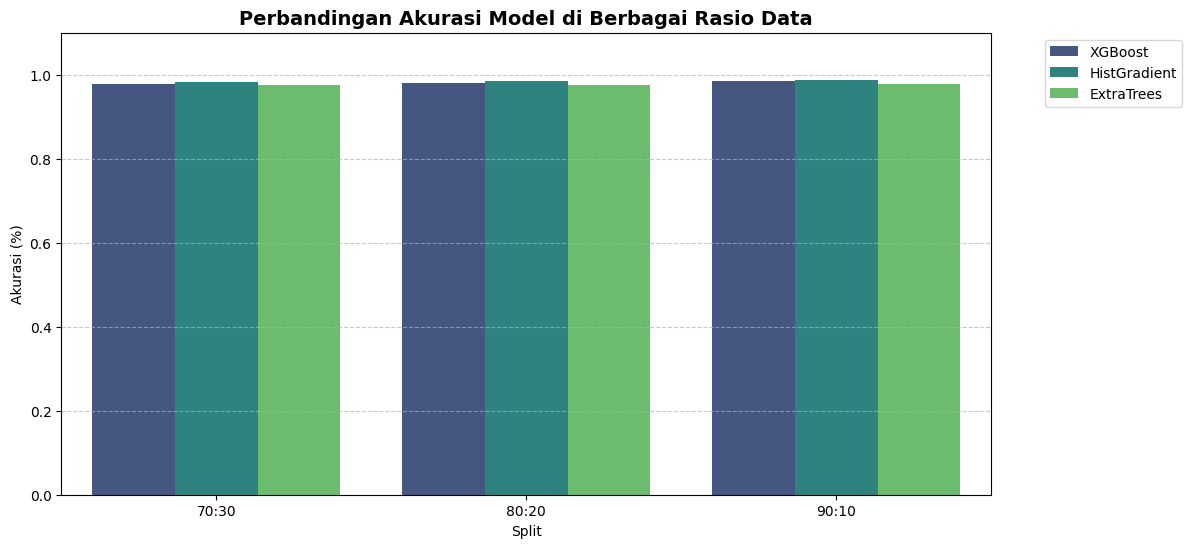

In [92]:
# 1. Ubah list hasil menjadi DataFrame agar rapi
df_hasil = pd.DataFrame(hasil_evaluasi)

print("=== 5. MODEL COMPARISON ===")

# Menampilkan Tabel Perbandingan (Urut berdasarkan akurasi tertinggi)
print("\nTabel Hasil Evaluasi Lengkap:")
display(df_hasil.sort_values(by=['Split', 'Accuracy'], ascending=[False, False]).reset_index(drop=True).round(2))

# Visualisasi Perbandingan Akurasi dengan Grafik Batang
plt.figure(figsize=(12, 6))
sns.barplot(data=df_hasil, x='Split', y='Accuracy', hue='Algoritma', palette='viridis')


plt.title('Perbandingan Akurasi Model di Berbagai Rasio Data', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Akurasi (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== 7. EVALUASI MENDALAM: SEMUA SPLITTING & ALGORITMA ===


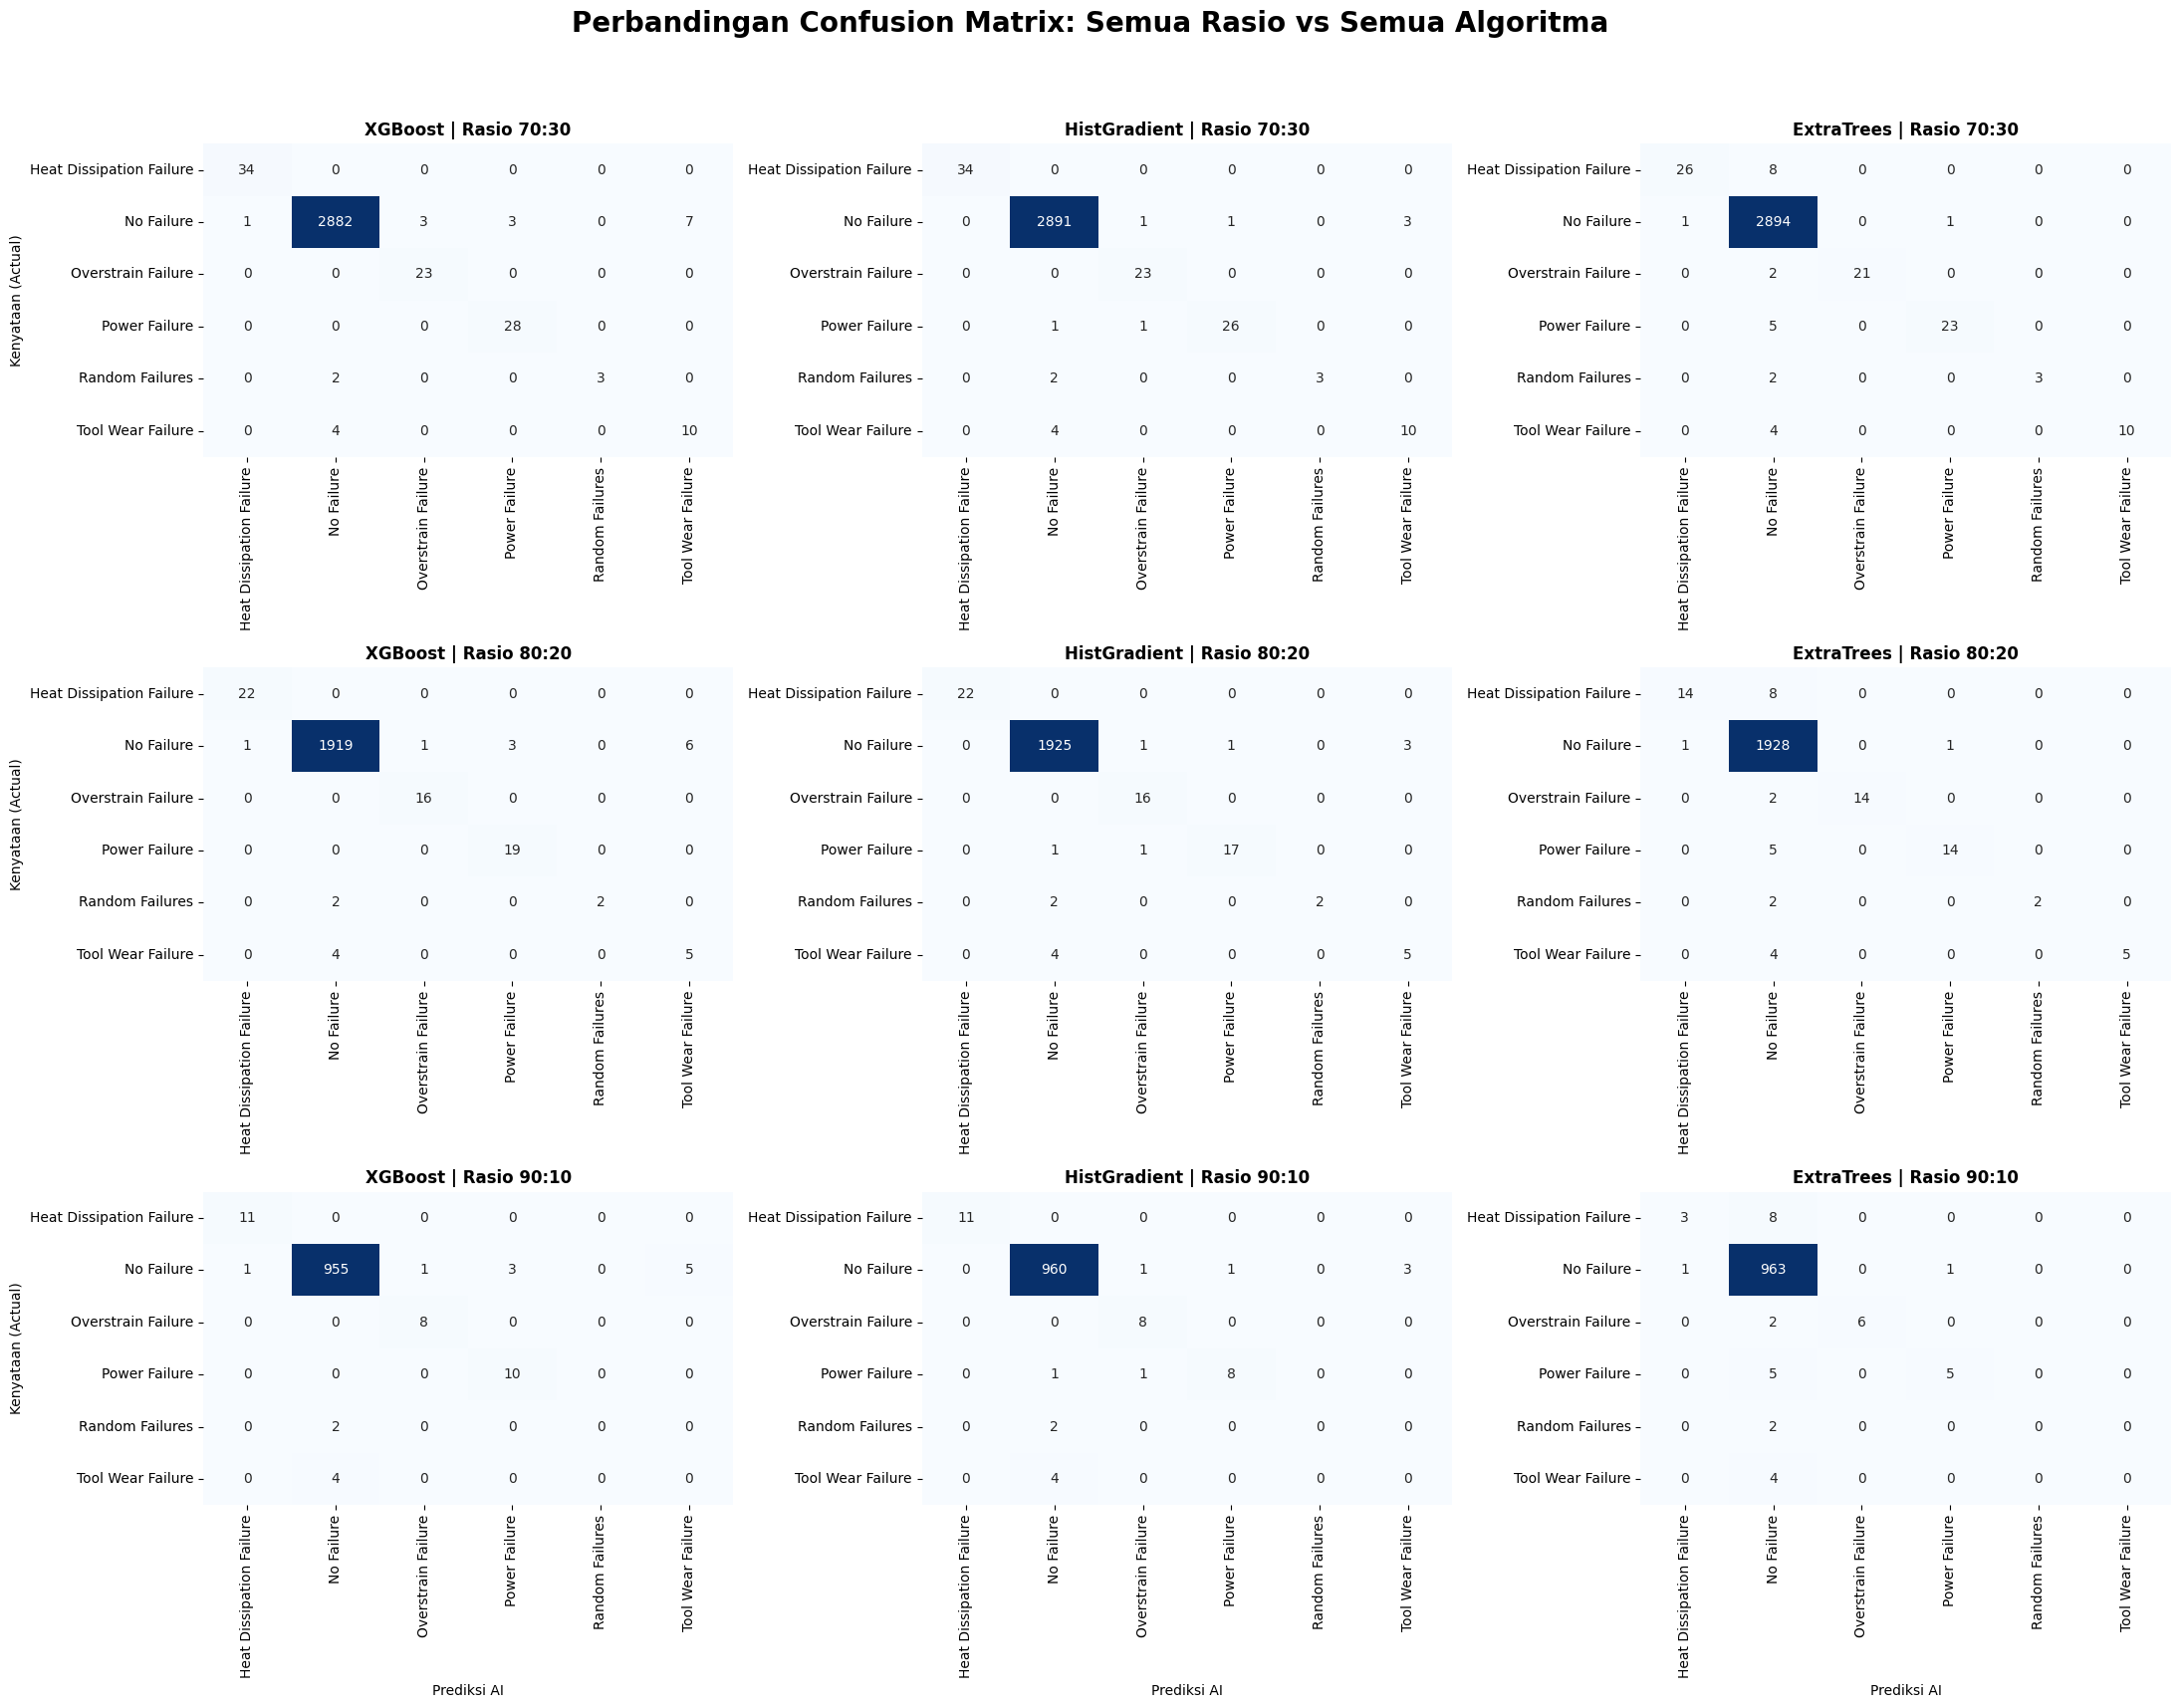

In [93]:
print("=== 7. EVALUASI MENDALAM: SEMUA SPLITTING & ALGORITMA ===")

# Menyiapkan canvas (3 baris untuk rasio, 3 kolom untuk algoritma)
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Perbandingan Confusion Matrix: Semua Rasio vs Semua Algoritma', fontsize=20, fontweight='bold')

# List algoritma dan rasio
nama_algoritma = list(models.keys())

for row, (rasio_nama, X_tr, X_ts, y_tr, y_ts) in enumerate(splits):
    for col, nama_model in enumerate(nama_algoritma):
        # Ambil model yang sudah dilatih
        model_saat_ini = models[nama_model]

        y_pred = model_saat_ini.predict(X_ts)
        
        # Hitung CM
        cm = confusion_matrix(y_ts, y_pred)
        
        # Gambar Heatmap di posisi baris dan kolom yang tepat
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                    xticklabels=le_target.classes_, 
                    yticklabels=le_target.classes_,
                    cbar=False)
        
        axes[row, col].set_title(f"{nama_model} | Rasio {rasio_nama}", fontsize=12, fontweight='bold')
        if row == 2: axes[row, col].set_xlabel('Prediksi AI')
        if col == 0: axes[row, col].set_ylabel('Kenyataan (Actual)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()